# 05 — Improved GA — Run & Visualize

This notebook runs the improved genetic algorithm with the target-independent random initialization, multi-mutation, fast rendering, and visualizes convergence, snapshots, and comparisons.

In [41]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.chdir(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.ga import run_ga, run_ga_islands
from src.fitness import load_target, evaluate
from src.rendering import render_individual_fast as render_individual

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

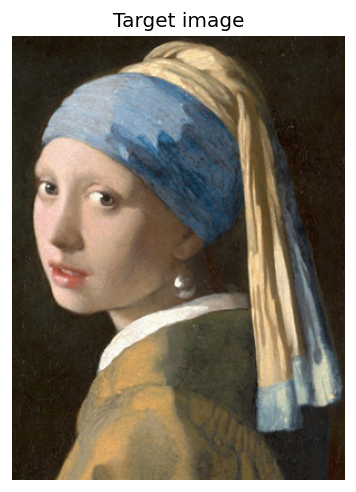

In [42]:
target = load_target()
plt.imshow(target)
plt.title("Target image")
plt.axis("off")
plt.show()

## 1. Improved GA run (final-quality defaults)

Running with: pop=150, generations=3000, rank selection, uniform crossover, multi mutation (rate=0.05), elite=2, local search=5, fast fitness, target-independent random initialization. The GA optimizes the downscaled fitness for speed, then evaluates the final individual at full resolution.

In [43]:
best_ind, best_fit, history = run_ga(
    target_image=target,
    pop_size=150,
    generations=3000,
    selection_method="rank",
    crossover_method="uniform",
    crossover_rate=0.8,
    mutation_method="multi",
    mutation_rate=0.05,
    sigma=10.0,
    elite_size=2,
    local_search_iterations=5,
    seed=42,
    fast_fitness=True,
    snapshot_interval=500,
    snapshot_dir="data/snapshots",
)
full_rmse = evaluate(best_ind, target, fitness_mode="rmse")
print(f"Final best fitness (downscaled): {best_fit:.4f}")
print(f"Final full-resolution RMSE: {full_rmse:.4f}")


Generation 1/500 | Best: 66.8100 | Avg: 74.3779
Generation 2/500 | Best: 66.1930 | Avg: 72.8308
Generation 3/500 | Best: 62.6715 | Avg: 70.9794
Generation 4/500 | Best: 62.6498 | Avg: 69.5161
Generation 5/500 | Best: 61.5126 | Avg: 68.2777
Generation 6/500 | Best: 61.2673 | Avg: 67.4115
Generation 7/500 | Best: 61.2549 | Avg: 66.7965
Generation 8/500 | Best: 59.0391 | Avg: 65.9081
Generation 9/500 | Best: 58.9659 | Avg: 65.4221
Generation 10/500 | Best: 58.7944 | Avg: 64.5518
Generation 11/500 | Best: 57.9541 | Avg: 63.4838
Generation 12/500 | Best: 57.8516 | Avg: 62.8978
Generation 13/500 | Best: 57.7705 | Avg: 62.1334
Generation 14/500 | Best: 57.5372 | Avg: 61.9341
Generation 15/500 | Best: 57.4711 | Avg: 61.4066
Generation 16/500 | Best: 57.2324 | Avg: 60.7322
Generation 17/500 | Best: 56.4607 | Avg: 60.3361
Generation 18/500 | Best: 56.3020 | Avg: 60.0562
Generation 19/500 | Best: 55.5330 | Avg: 59.7412
Generation 20/500 | Best: 55.2103 | Avg: 59.4302
Generation 21/500 | Best: 55.

### 1.1 Convergence curve

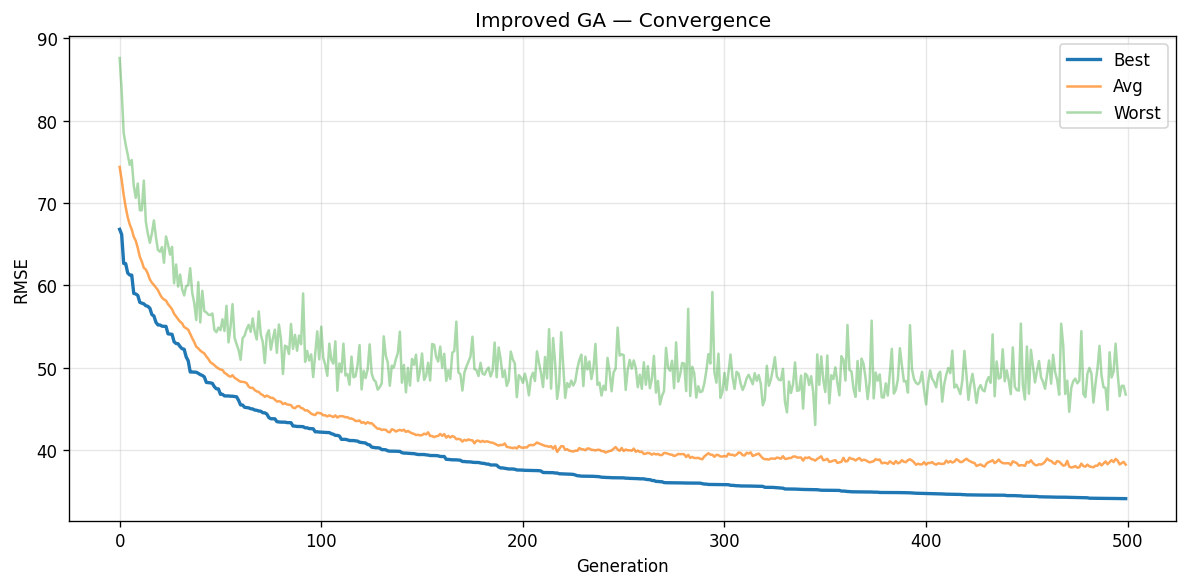

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["best_fitness"], label="Best", linewidth=2)
ax.plot(history["avg_fitness"], label="Avg", alpha=0.7)
ax.plot(history["worst_fitness"], label="Worst", alpha=0.4)
ax.set_xlabel("Generation")
ax.set_ylabel("RMSE")
ax.set_title("Improved GA — Convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Result vs Target

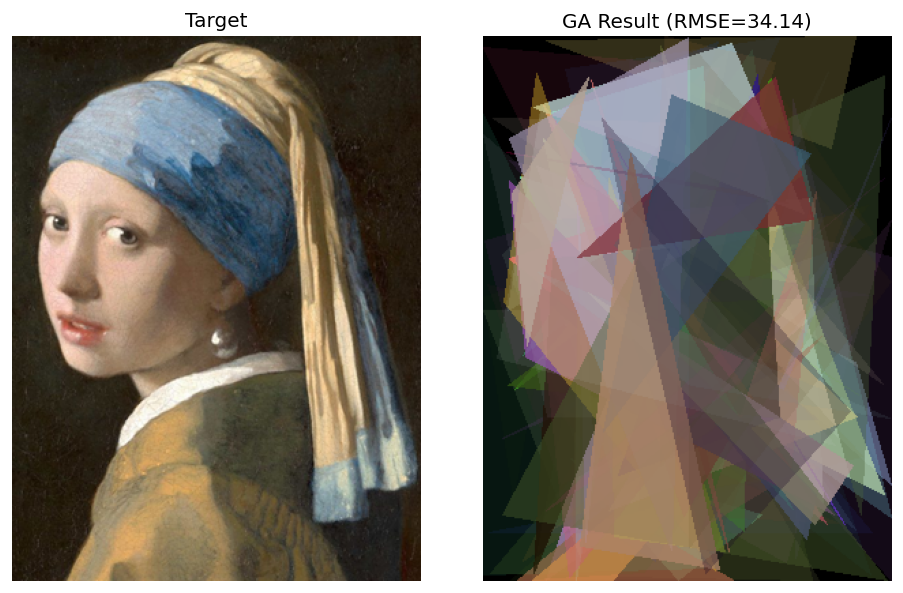

In [45]:
result_img = render_individual(best_ind)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(target)
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_img)
axes[1].set_title(f"GA Result (RMSE={best_fit:.2f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Mutation method comparison

Compare the new `multi` mutation against the previous best (`vertex_jitter`) and `adaptive_vertex_jitter`.

In [46]:
mutation_methods = ["vertex_jitter", "multi", "adaptive_vertex_jitter"]
mutation_results = {}

for mm in mutation_methods:
    print(f"\n--- Running: {mm} ---")
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=100,
        generations=200,
        selection_method="rank",
        crossover_method="uniform",
        crossover_rate=0.8,
        mutation_method=mm,
        mutation_rate=0.05,
        sigma=10.0,
        elite_size=2,
        seed=42,
    )
    mutation_results[mm] = {"individual": ind, "fitness": fit, "history": hist}
    print(f"{mm}: RMSE = {fit:.4f}")


--- Running: vertex_jitter ---
Generation 1/200 | Best: 66.8139 | Avg: 74.8355
Generation 2/200 | Best: 65.2761 | Avg: 73.4143
Generation 3/200 | Best: 64.8185 | Avg: 71.3023
Generation 4/200 | Best: 64.2516 | Avg: 69.8769
Generation 5/200 | Best: 64.0958 | Avg: 68.8489
Generation 6/200 | Best: 63.1573 | Avg: 67.6369
Generation 7/200 | Best: 61.9413 | Avg: 66.6203
Generation 8/200 | Best: 61.3139 | Avg: 66.0470
Generation 9/200 | Best: 60.1046 | Avg: 65.5927
Generation 10/200 | Best: 59.5737 | Avg: 64.7693
Generation 11/200 | Best: 58.7663 | Avg: 63.7714
Generation 12/200 | Best: 58.7663 | Avg: 62.7596
Generation 13/200 | Best: 58.6238 | Avg: 61.7661
Generation 14/200 | Best: 57.9545 | Avg: 60.7656
Generation 15/200 | Best: 56.1079 | Avg: 59.9257
Generation 16/200 | Best: 56.1079 | Avg: 59.1426
Generation 17/200 | Best: 55.8187 | Avg: 58.5500
Generation 18/200 | Best: 54.8586 | Avg: 58.1008
Generation 19/200 | Best: 54.8586 | Avg: 57.5006
Generation 20/200 | Best: 54.5630 | Avg: 56.89

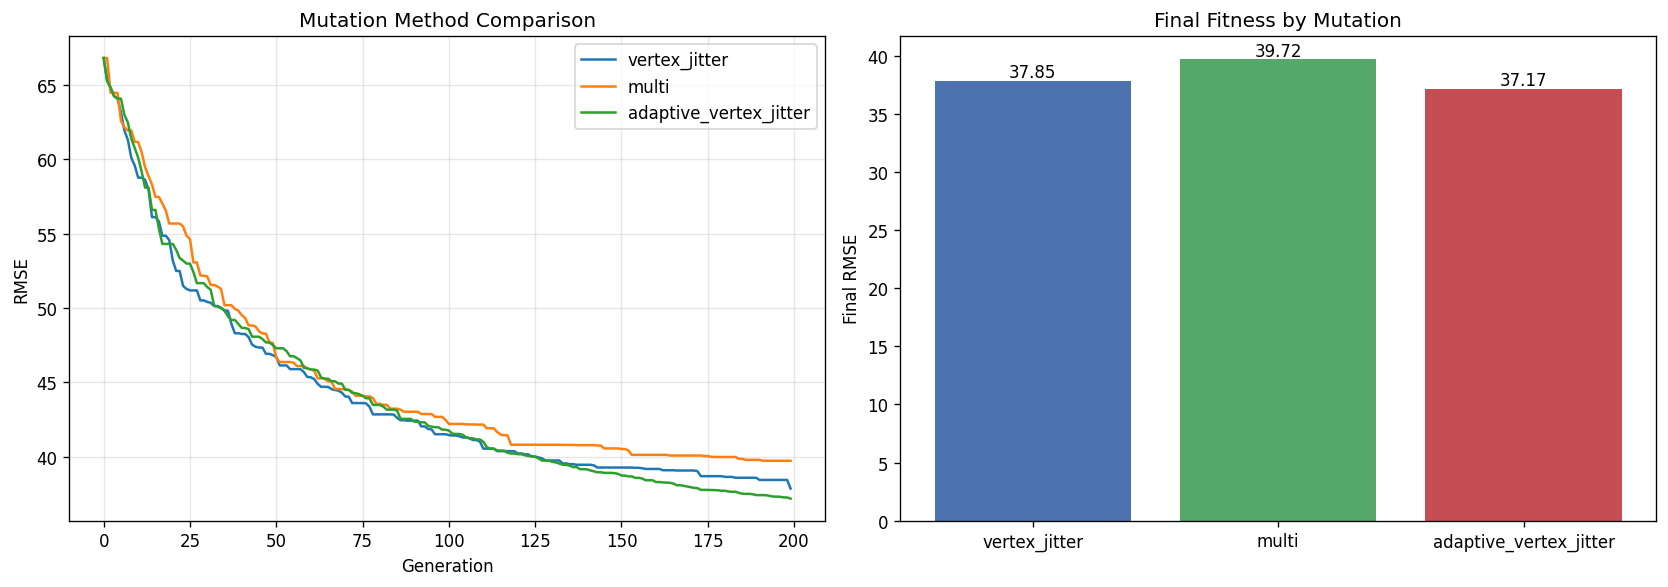

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence curves
for mm in mutation_methods:
    axes[0].plot(mutation_results[mm]["history"]["best_fitness"], label=mm)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Mutation Method Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final RMSE bar chart
names = list(mutation_results.keys())
values = [mutation_results[m]["fitness"] for m in names]
bars = axes[1].bar(names, values, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_ylabel("Final RMSE")
axes[1].set_title("Final Fitness by Mutation")
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

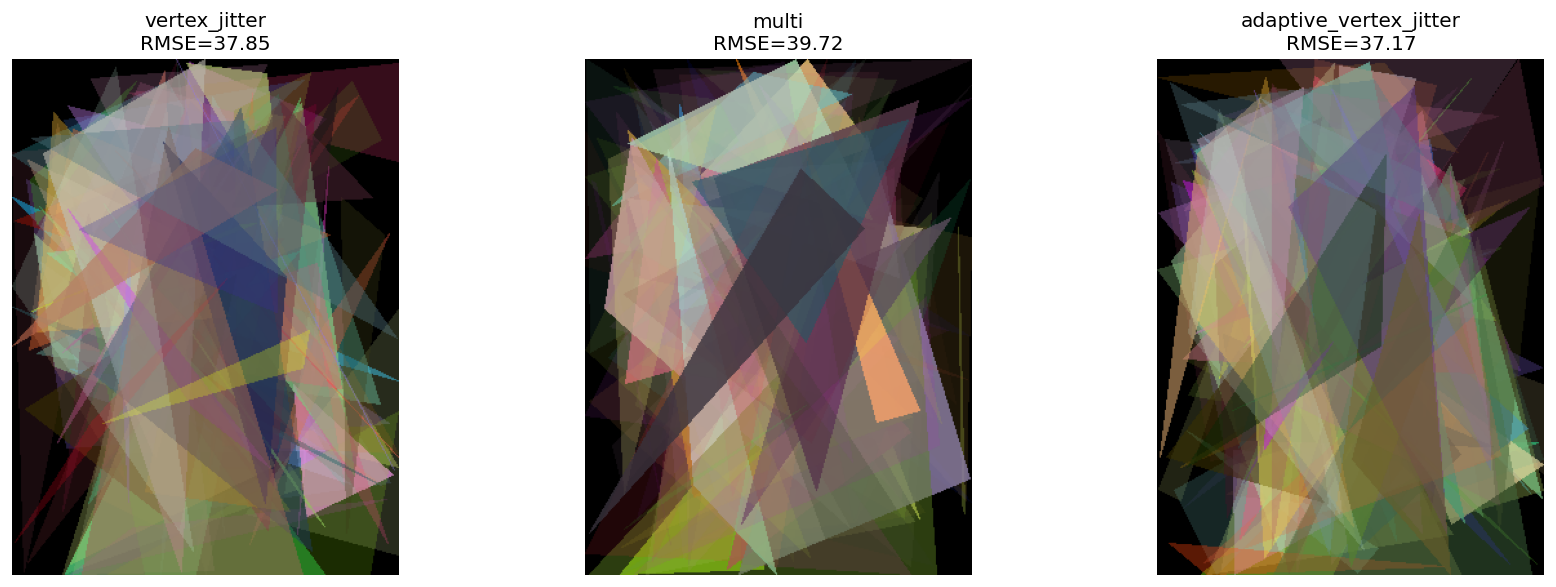

In [48]:
fig, axes = plt.subplots(1, len(mutation_methods), figsize=(5 * len(mutation_methods), 5))
for i, mm in enumerate(mutation_methods):
    img = render_individual(mutation_results[mm]["individual"])
    axes[i].imshow(img)
    axes[i].set_title(f"{mm}\nRMSE={mutation_results[mm]['fitness']:.2f}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 3. Crossover comparison

Compare `uniform`, `blend`, and `fitness_weighted_blend` crossover methods.

In [49]:
crossover_methods = ["uniform", "blend", "fitness_weighted_blend"]
crossover_results = {}

for cm in crossover_methods:
    print(f"\n--- Running: {cm} ---")
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=100,
        generations=200,
        selection_method="rank",
        crossover_method=cm,
        crossover_rate=0.8,
        mutation_method="multi",
        mutation_rate=0.05,
        sigma=10.0,
        elite_size=2,
        seed=42,
    )
    crossover_results[cm] = {"individual": ind, "fitness": fit, "history": hist}
    print(f"{cm}: RMSE = {fit:.4f}")


--- Running: uniform ---
Generation 1/200 | Best: 66.8139 | Avg: 74.8355
Generation 2/200 | Best: 66.8139 | Avg: 72.8873
Generation 3/200 | Best: 64.4797 | Avg: 71.8652
Generation 4/200 | Best: 64.4708 | Avg: 71.0327
Generation 5/200 | Best: 64.4708 | Avg: 70.0895
Generation 6/200 | Best: 62.6109 | Avg: 68.8040
Generation 7/200 | Best: 62.1556 | Avg: 67.8279
Generation 8/200 | Best: 61.9369 | Avg: 67.1908
Generation 9/200 | Best: 61.9369 | Avg: 65.8132
Generation 10/200 | Best: 61.1812 | Avg: 65.2433
Generation 11/200 | Best: 61.1619 | Avg: 64.5941
Generation 12/200 | Best: 60.4763 | Avg: 64.0089
Generation 13/200 | Best: 59.4676 | Avg: 63.6862
Generation 14/200 | Best: 58.8662 | Avg: 63.1931
Generation 15/200 | Best: 58.2894 | Avg: 62.2238
Generation 16/200 | Best: 57.4718 | Avg: 61.7228
Generation 17/200 | Best: 57.4718 | Avg: 61.1920
Generation 18/200 | Best: 57.0258 | Avg: 60.5740
Generation 19/200 | Best: 56.5505 | Avg: 60.1196
Generation 20/200 | Best: 55.6778 | Avg: 59.5562
Gen

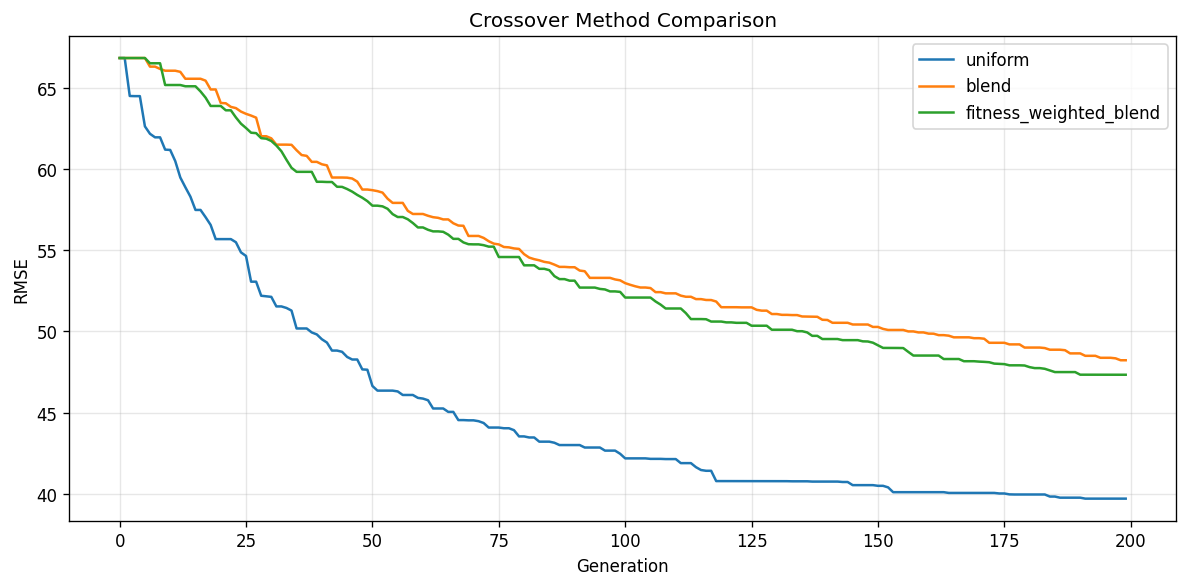

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
for cm in crossover_methods:
    ax.plot(crossover_results[cm]["history"]["best_fitness"], label=cm)
ax.set_xlabel("Generation")
ax.set_ylabel("RMSE")
ax.set_title("Crossover Method Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Fast fitness vs full-resolution fitness

Compare runtime and quality between downscaled (150x200) and full-resolution (300x400) fitness evaluation.

In [51]:
import time

speed_results = {}
for label, fast in [("Full-res", False), ("Downscaled", True)]:
    print(f"\n--- {label} ---")
    t0 = time.time()
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=100,
        generations=100,
        selection_method="rank",
        crossover_method="uniform",
        crossover_rate=0.8,
        mutation_method="multi",
        mutation_rate=0.05,
        sigma=10.0,
        elite_size=2,
        seed=42,
        fast_fitness=fast,
    )
    elapsed = time.time() - t0
    speed_results[label] = {"individual": ind, "fitness": fit, "history": hist, "time": elapsed}
    print(f"{label}: RMSE={fit:.4f}, time={elapsed:.1f}s")


--- Full-res ---
Generation 1/100 | Best: 66.8139 | Avg: 74.8355
Generation 2/100 | Best: 66.8139 | Avg: 72.8873
Generation 3/100 | Best: 64.4797 | Avg: 71.8652
Generation 4/100 | Best: 64.4708 | Avg: 71.0327
Generation 5/100 | Best: 64.4708 | Avg: 70.0895
Generation 6/100 | Best: 62.6109 | Avg: 68.8040
Generation 7/100 | Best: 62.1556 | Avg: 67.8279
Generation 8/100 | Best: 61.9369 | Avg: 67.1908
Generation 9/100 | Best: 61.9369 | Avg: 65.8132
Generation 10/100 | Best: 61.1812 | Avg: 65.2433
Generation 11/100 | Best: 61.1619 | Avg: 64.5941
Generation 12/100 | Best: 60.4763 | Avg: 64.0089
Generation 13/100 | Best: 59.4676 | Avg: 63.6862
Generation 14/100 | Best: 58.8662 | Avg: 63.1931
Generation 15/100 | Best: 58.2894 | Avg: 62.2238
Generation 16/100 | Best: 57.4718 | Avg: 61.7228
Generation 17/100 | Best: 57.4718 | Avg: 61.1920
Generation 18/100 | Best: 57.0258 | Avg: 60.5740
Generation 19/100 | Best: 56.5505 | Avg: 60.1196
Generation 20/100 | Best: 55.6778 | Avg: 59.5562
Generation 

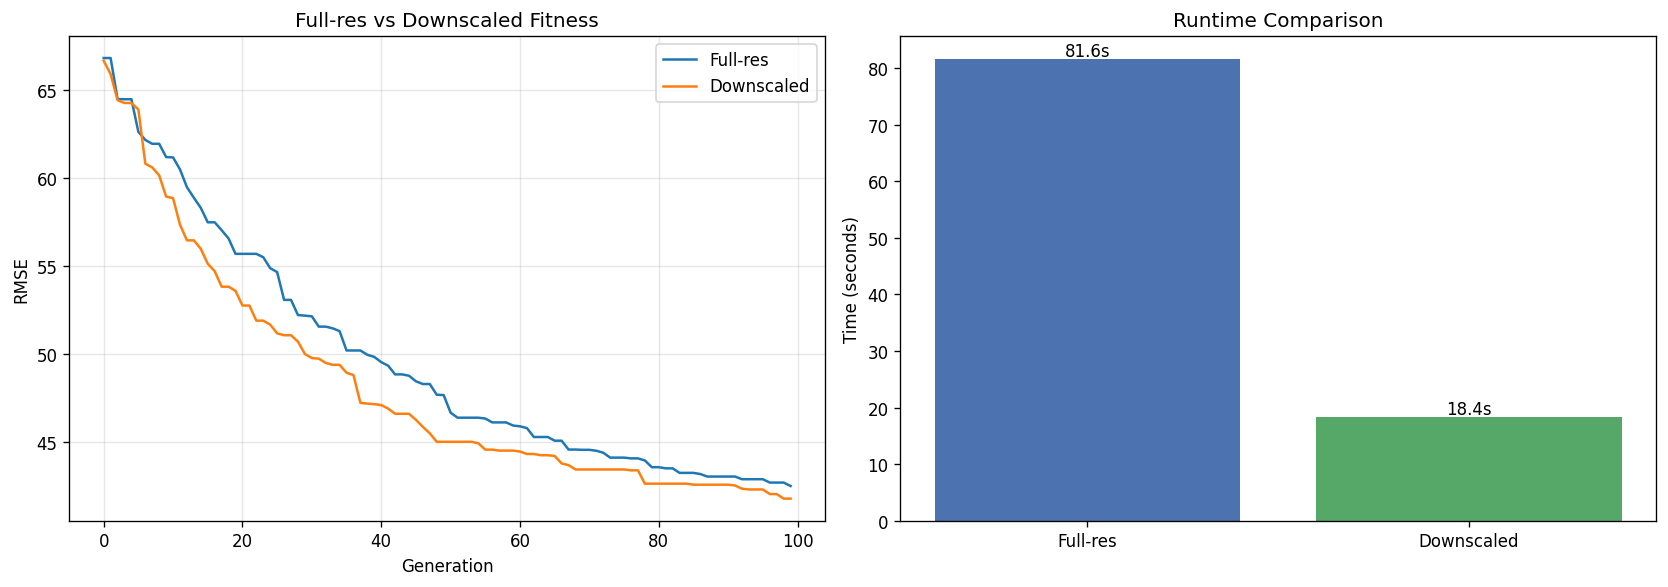

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in speed_results:
    axes[0].plot(speed_results[label]["history"]["best_fitness"], label=label)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Full-res vs Downscaled Fitness")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

labels = list(speed_results.keys())
times = [speed_results[l]["time"] for l in labels]
bars = axes[1].bar(labels, times, color=["#4C72B0", "#55A868"])
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Runtime Comparison")
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{t:.1f}s", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Fitness mode comparison

Compare `rmse`, `hybrid` (RMSE + SSIM), and `perceptual` (luminance-weighted RMSE).

In [53]:
from src.fitness import evaluate

fitness_modes = ["rmse", "hybrid", "perceptual"]
fitness_results = {}

for fm in fitness_modes:
    print(f"\n--- Fitness mode: {fm} ---")
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=100,
        generations=200,
        selection_method="rank",
        crossover_method="uniform",
        crossover_rate=0.8,
        mutation_method="multi",
        mutation_rate=0.05,
        sigma=10.0,
        elite_size=2,
        seed=42,
        fitness_mode=fm,
    )
    # Always evaluate final RMSE for fair comparison
    final_rmse = evaluate(ind, target, fitness_mode="rmse")
    fitness_results[fm] = {"individual": ind, "fitness": fit, "history": hist, "rmse": final_rmse}
    print(f"{fm}: native={fit:.4f}, RMSE={final_rmse:.4f}")


--- Fitness mode: rmse ---
Generation 1/200 | Best: 66.8139 | Avg: 74.8355
Generation 2/200 | Best: 66.8139 | Avg: 72.8873
Generation 3/200 | Best: 64.4797 | Avg: 71.8652
Generation 4/200 | Best: 64.4708 | Avg: 71.0327
Generation 5/200 | Best: 64.4708 | Avg: 70.0895
Generation 6/200 | Best: 62.6109 | Avg: 68.8040
Generation 7/200 | Best: 62.1556 | Avg: 67.8279
Generation 8/200 | Best: 61.9369 | Avg: 67.1908
Generation 9/200 | Best: 61.9369 | Avg: 65.8132
Generation 10/200 | Best: 61.1812 | Avg: 65.2433
Generation 11/200 | Best: 61.1619 | Avg: 64.5941
Generation 12/200 | Best: 60.4763 | Avg: 64.0089
Generation 13/200 | Best: 59.4676 | Avg: 63.6862
Generation 14/200 | Best: 58.8662 | Avg: 63.1931
Generation 15/200 | Best: 58.2894 | Avg: 62.2238
Generation 16/200 | Best: 57.4718 | Avg: 61.7228
Generation 17/200 | Best: 57.4718 | Avg: 61.1920
Generation 18/200 | Best: 57.0258 | Avg: 60.5740
Generation 19/200 | Best: 56.5505 | Avg: 60.1196
Generation 20/200 | Best: 55.6778 | Avg: 59.5562
G

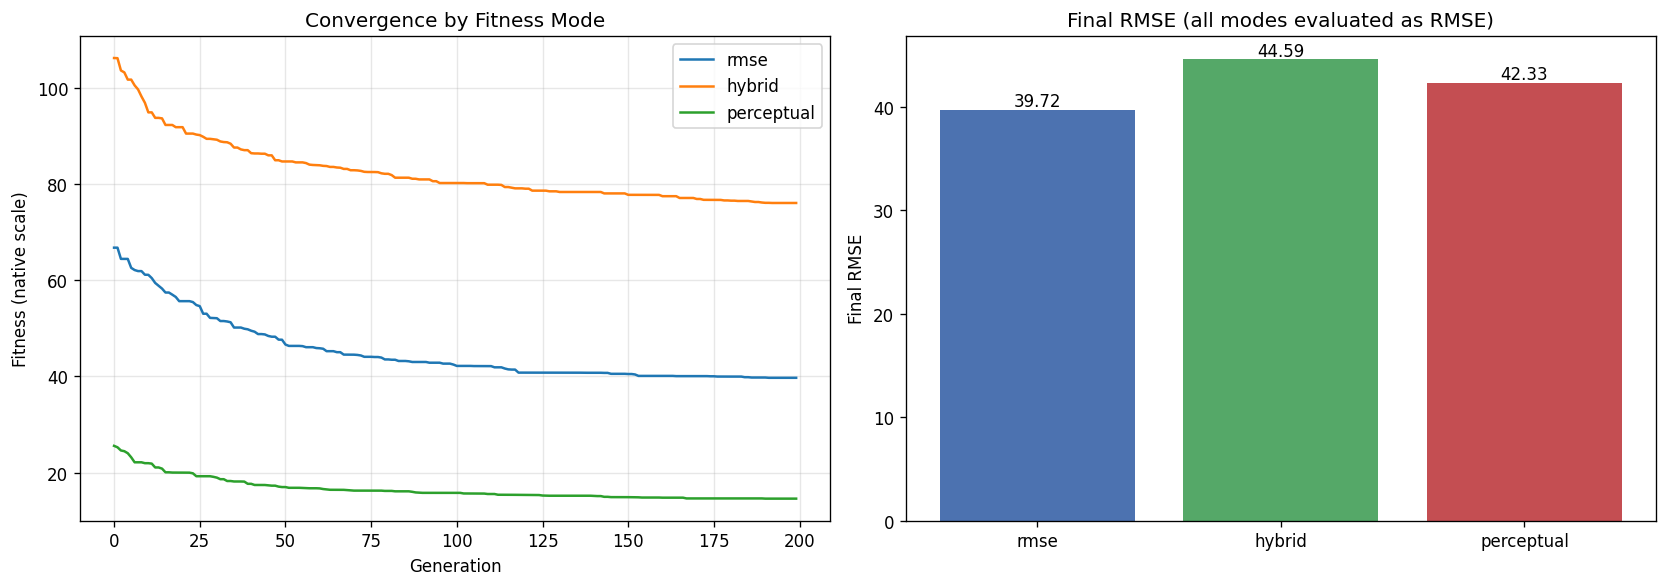

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence (native fitness — different scales)
for fm in fitness_modes:
    axes[0].plot(fitness_results[fm]["history"]["best_fitness"], label=fm)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness (native scale)")
axes[0].set_title("Convergence by Fitness Mode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final RMSE (fair comparison)
names = list(fitness_results.keys())
rmse_vals = [fitness_results[m]["rmse"] for m in names]
bars = axes[1].bar(names, rmse_vals, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_ylabel("Final RMSE")
axes[1].set_title("Final RMSE (all modes evaluated as RMSE)")
for bar, v in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

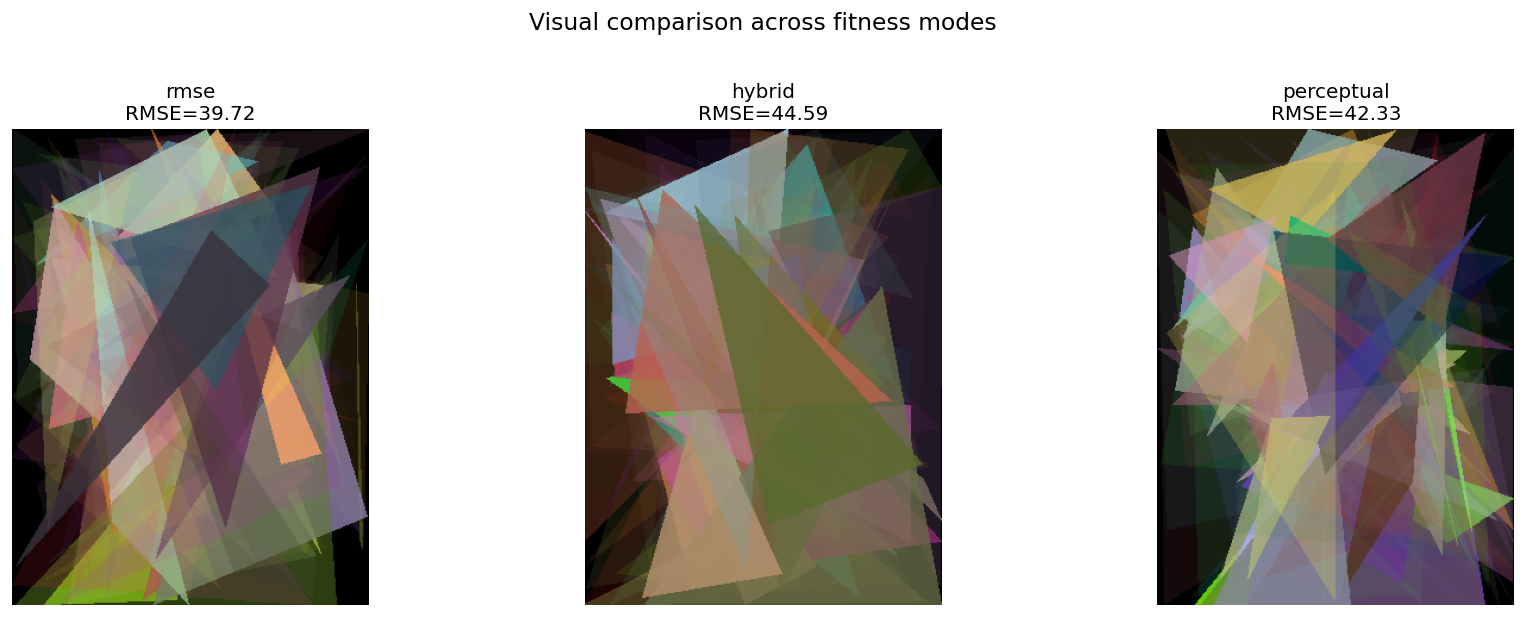

In [55]:
fig, axes = plt.subplots(1, len(fitness_modes), figsize=(5 * len(fitness_modes), 5))
for i, fm in enumerate(fitness_modes):
    img = render_individual(fitness_results[fm]["individual"])
    axes[i].imshow(img)
    axes[i].set_title(f"{fm}\nRMSE={fitness_results[fm]['rmse']:.2f}")
    axes[i].axis("off")
plt.suptitle("Visual comparison across fitness modes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Local search (memetic GA)

Compare no local search vs 3 and 5 iterations of hill climbing on elite individuals.

In [56]:
ls_configs = [0, 3, 5]
ls_results = {}

for ls in ls_configs:
    label = f"ls={ls}"
    print(f"\n--- {label} ---")
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=100,
        generations=200,
        selection_method="rank",
        crossover_method="uniform",
        crossover_rate=0.8,
        mutation_method="multi",
        mutation_rate=0.05,
        sigma=10.0,
        elite_size=2,
        seed=42,
        local_search_iterations=ls,
    )
    ls_results[label] = {"individual": ind, "fitness": fit, "history": hist}
    print(f"{label}: RMSE = {fit:.4f}")


--- ls=0 ---
Generation 1/200 | Best: 66.8139 | Avg: 74.8355
Generation 2/200 | Best: 66.8139 | Avg: 72.8873
Generation 3/200 | Best: 64.4797 | Avg: 71.8652
Generation 4/200 | Best: 64.4708 | Avg: 71.0327
Generation 5/200 | Best: 64.4708 | Avg: 70.0895
Generation 6/200 | Best: 62.6109 | Avg: 68.8040
Generation 7/200 | Best: 62.1556 | Avg: 67.8279
Generation 8/200 | Best: 61.9369 | Avg: 67.1908
Generation 9/200 | Best: 61.9369 | Avg: 65.8132
Generation 10/200 | Best: 61.1812 | Avg: 65.2433
Generation 11/200 | Best: 61.1619 | Avg: 64.5941
Generation 12/200 | Best: 60.4763 | Avg: 64.0089
Generation 13/200 | Best: 59.4676 | Avg: 63.6862
Generation 14/200 | Best: 58.8662 | Avg: 63.1931
Generation 15/200 | Best: 58.2894 | Avg: 62.2238
Generation 16/200 | Best: 57.4718 | Avg: 61.7228
Generation 17/200 | Best: 57.4718 | Avg: 61.1920
Generation 18/200 | Best: 57.0258 | Avg: 60.5740
Generation 19/200 | Best: 56.5505 | Avg: 60.1196
Generation 20/200 | Best: 55.6778 | Avg: 59.5562
Generation 21/2

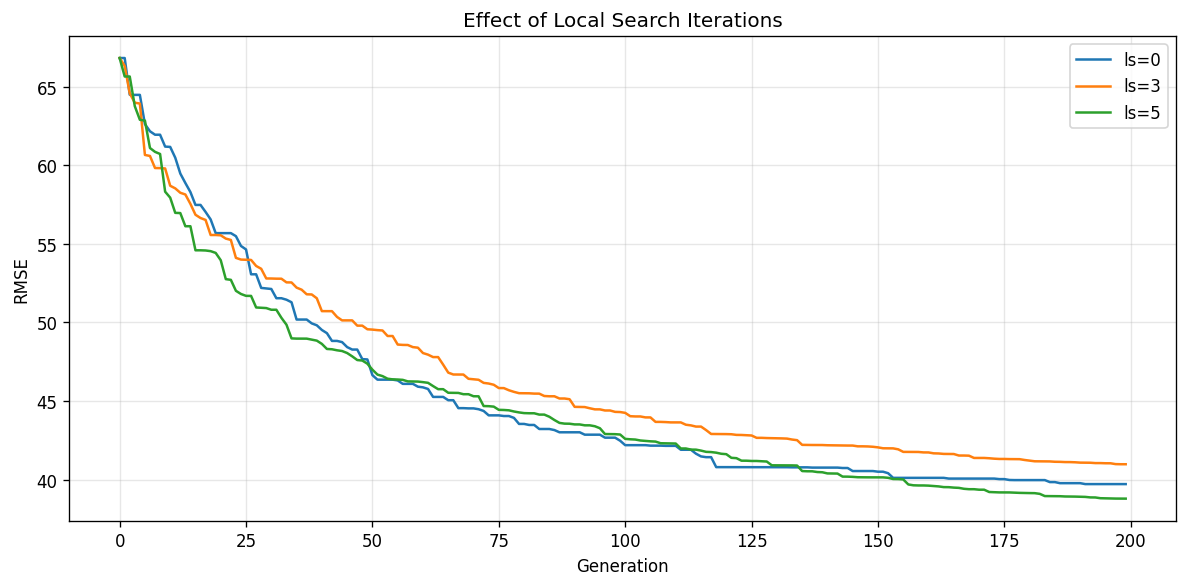

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
for label in ls_results:
    ax.plot(ls_results[label]["history"]["best_fitness"], label=label)
ax.set_xlabel("Generation")
ax.set_ylabel("RMSE")
ax.set_title("Effect of Local Search Iterations")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Island model

Compare standard GA vs island model (4 islands, migration every 50 generations).

In [58]:
print("--- Standard GA ---")
std_ind, std_fit, std_hist = run_ga(
    target_image=target,
    pop_size=100,
    generations=200,
    selection_method="rank",
    crossover_method="uniform",
    crossover_rate=0.8,
    mutation_method="multi",
    mutation_rate=0.05,
    sigma=10.0,
    elite_size=2,
    seed=42,
)
print(f"Standard: RMSE = {std_fit:.4f}")

print("\n--- Island Model ---")
isl_ind, isl_fit, isl_hist = run_ga_islands(
    target_image=target,
    num_islands=4,
    migration_interval=50,
    migration_size=2,
    pop_size=100,
    generations=200,
    selection_method="rank",
    crossover_method="uniform",
    crossover_rate=0.8,
    mutation_method="multi",
    mutation_rate=0.05,
    sigma=10.0,
    elite_size=2,
    seed=42,
)
print(f"Islands: RMSE = {isl_fit:.4f}")

--- Standard GA ---
Generation 1/200 | Best: 66.8139 | Avg: 74.8355
Generation 2/200 | Best: 66.8139 | Avg: 72.8873
Generation 3/200 | Best: 64.4797 | Avg: 71.8652
Generation 4/200 | Best: 64.4708 | Avg: 71.0327
Generation 5/200 | Best: 64.4708 | Avg: 70.0895
Generation 6/200 | Best: 62.6109 | Avg: 68.8040
Generation 7/200 | Best: 62.1556 | Avg: 67.8279
Generation 8/200 | Best: 61.9369 | Avg: 67.1908
Generation 9/200 | Best: 61.9369 | Avg: 65.8132
Generation 10/200 | Best: 61.1812 | Avg: 65.2433
Generation 11/200 | Best: 61.1619 | Avg: 64.5941
Generation 12/200 | Best: 60.4763 | Avg: 64.0089
Generation 13/200 | Best: 59.4676 | Avg: 63.6862
Generation 14/200 | Best: 58.8662 | Avg: 63.1931
Generation 15/200 | Best: 58.2894 | Avg: 62.2238
Generation 16/200 | Best: 57.4718 | Avg: 61.7228
Generation 17/200 | Best: 57.4718 | Avg: 61.1920
Generation 18/200 | Best: 57.0258 | Avg: 60.5740
Generation 19/200 | Best: 56.5505 | Avg: 60.1196
Generation 20/200 | Best: 55.6778 | Avg: 59.5562
Generatio

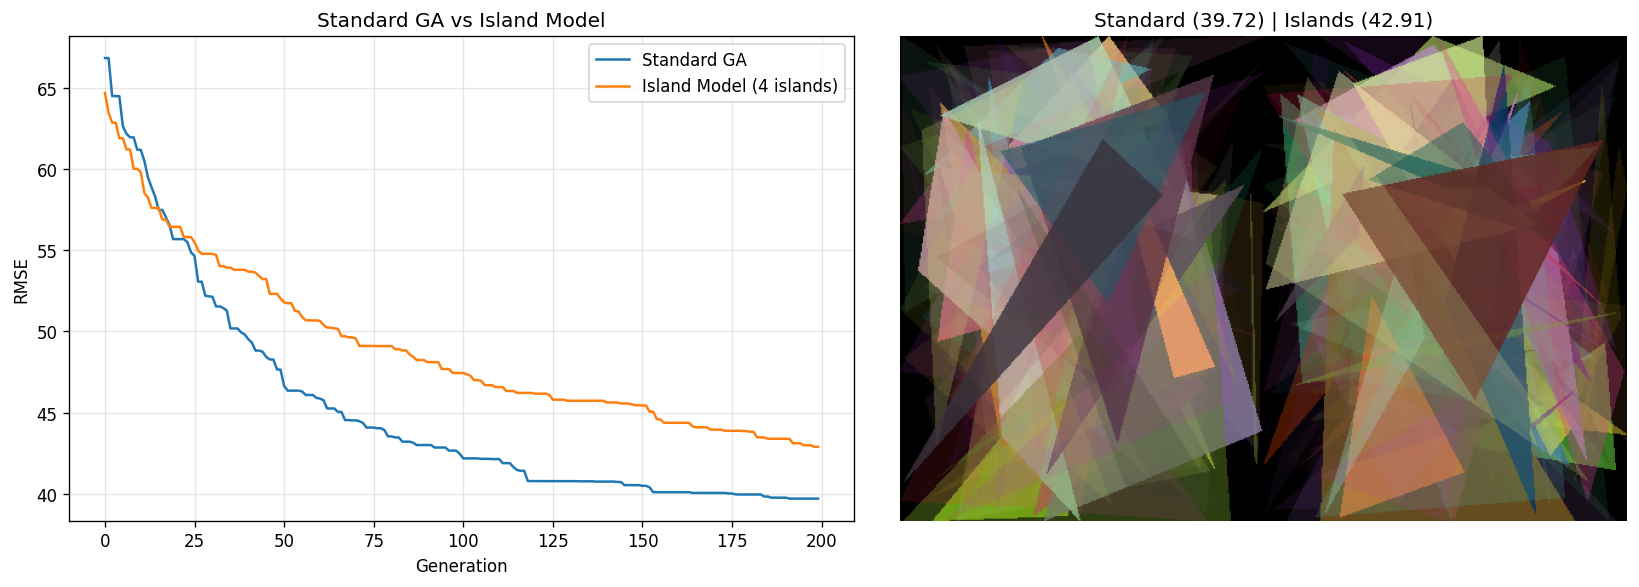

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(std_hist["best_fitness"], label="Standard GA")
axes[0].plot(isl_hist["best_fitness"], label="Island Model (4 islands)")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Standard GA vs Island Model")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

std_img = render_individual(std_ind)
isl_img = render_individual(isl_ind)
combined = np.hstack([std_img, isl_img])
axes[1].imshow(combined)
axes[1].set_title(f"Standard ({std_fit:.2f}) | Islands ({isl_fit:.2f})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 8. Summary table

In [60]:
import pandas as pd

rows = []

# Mutation comparison
for mm in mutation_results:
    rows.append({"Experiment": f"mutation={mm}", "RMSE": mutation_results[mm]["fitness"]})

# Crossover comparison
for cm in crossover_results:
    rows.append({"Experiment": f"crossover={cm}", "RMSE": crossover_results[cm]["fitness"]})

# Fitness mode comparison
for fm in fitness_results:
    rows.append({"Experiment": f"fitness_mode={fm}", "RMSE": fitness_results[fm]["rmse"]})

# Local search
for label in ls_results:
    rows.append({"Experiment": f"local_search ({label})", "RMSE": ls_results[label]["fitness"]})

# Island model
rows.append({"Experiment": "standard_ga", "RMSE": std_fit})
rows.append({"Experiment": "island_model", "RMSE": isl_fit})

df = pd.DataFrame(rows).sort_values("RMSE")
df.reset_index(drop=True, inplace=True)
df

,Experiment,RMSE
0,mutation=adaptive_vertex_jitter,37.168339
1,mutation=vertex_jitter,37.847595
2,local_search (ls=5),38.793301
3,mutation=multi,39.717777
4,local_search (ls=0),39.717777
5,standard_ga,39.717777
6,crossover=uniform,39.717777
7,fitness_mode=rmse,39.717779
8,local_search (ls=3),40.980721
9,fitness_mode=perceptual,42.326124
